In [23]:
import numpy as np

input_data = np.load('initial_data/function_3/initial_inputs.npy')
print("Before:", input_data.shape)
new_point = np.array([
    [0.754364, 0.233177, 0.303208],
    [0.312229, 0.060777, 0.000904]
    ])
input_data = np.vstack([input_data, new_point])
print("After:", input_data.shape)
print(input_data)


Before: (15, 3)
After: (17, 3)
[[1.71525207e-01 3.43916870e-01 2.48737201e-01]
 [2.42114461e-01 6.44074270e-01 2.72432809e-01]
 [5.34905720e-01 3.98500915e-01 1.73388729e-01]
 [4.92581415e-01 6.11593188e-01 3.40176386e-01]
 [1.34621666e-01 2.19917240e-01 4.58206220e-01]
 [3.45523271e-01 9.41359831e-01 2.69363479e-01]
 [1.51836632e-01 4.39990619e-01 9.90881867e-01]
 [6.45502835e-01 3.97142940e-01 9.19771338e-01]
 [7.46911945e-01 2.84196309e-01 2.26299855e-01]
 [1.70476994e-01 6.97032401e-01 1.49169434e-01]
 [2.20549337e-01 2.97825244e-01 3.43555344e-01]
 [6.66013659e-01 6.71985151e-01 2.46295297e-01]
 [4.68089497e-02 2.31360241e-01 7.70617592e-01]
 [6.00097282e-01 7.25135725e-01 6.60886415e-02]
 [9.65994849e-01 8.61119690e-01 5.66829131e-01]
 [7.54364000e-01 2.33177000e-01 3.03208000e-01]
 [3.12229000e-01 6.07770000e-02 9.04000000e-04]]


In [24]:
output_data = np.load('initial_data/function_3/initial_outputs.npy')
print("Before:", output_data.shape)
new_output = np.array([
    -0.09200841551496666,
    -0.18083748652026374,
    ])
output_data = np.append(output_data, new_output)
print("After:", output_data.shape)
print(output_data)


Before: (15,)
After: (17,)
[-0.1121222  -0.08796286 -0.11141465 -0.03483531 -0.04800758 -0.11062091
 -0.39892551 -0.11386851 -0.13146061 -0.09418956 -0.04694741 -0.10596504
 -0.11804826 -0.03637783 -0.05675837 -0.09200842 -0.18083749]


In [26]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [27]:
# Outputs span extreme ranges, so fit SVR in log|y| space
log_y = np.log(np.abs(output_data))

scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(input_data)

print(f"log|y| range: [{log_y.min():.1f}, {log_y.max():.1f}]")
print(f"Negative outputs: {(output_data < 0).sum()} / {len(output_data)}")

log|y| range: [-3.4, -0.9]
Negative outputs: 17 / 17


In [28]:
svr = SVR(kernel='rbf', C=100.0, epsilon=0.5, gamma='scale')
svr.fit(X_scaled, log_y)

log_y_pred = svr.predict(X_scaled)
print(f"In-sample MSE (log space): {mean_squared_error(log_y, log_y_pred):.4f}")
print(f"In-sample R²  (log space): {r2_score(log_y, log_y_pred):.4f}")


In-sample MSE (log space): 0.1784
In-sample R²  (log space): 0.4850


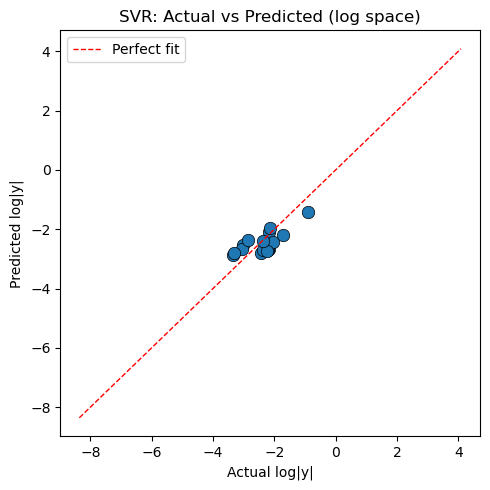

In [29]:
from scipy.stats import norm
plt.figure(figsize=(5, 5))
plt.scatter(log_y, log_y_pred, edgecolors='black', linewidths=0.5, s=80)
lims = [log_y.min() - 5, log_y.max() + 5]
plt.plot(lims, lims, 'r--', linewidth=1, label='Perfect fit')
plt.xlabel('Actual log|y|')
plt.ylabel('Predicted log|y|')
plt.title('SVR: Actual vs Predicted (log space)')
plt.legend()
plt.tight_layout()
plt.show()


In [33]:
query = np.array([[0.5, 0.5, 0.5]])
log_pred = svr.predict(scaler_X.transform(query))[0]

actual_output = -0.015979341188442648
actual_log    = np.log(np.abs(actual_output))

pred_output   = np.exp(log_pred)
abs_error     = np.abs(pred_output - actual_output)
rel_error     = abs_error / np.abs(actual_output) * 100

print(f"Query point:           {query[0]}")
print(f"Predicted log|output|: {log_pred:.4f}")
print(f"Actual    log|output|: {actual_log:.4f}")
print(f"Predicted |output|:    {pred_output:.4e}")
print(f"Actual    |output|:    {actual_output:.4e}")
print(f"Absolute error:        {abs_error:.4e}")
print(f"Relative error:        {rel_error:.2f}%")    

Query point:           [0.5 0.5 0.5]
Predicted log|output|: -2.6408
Actual    log|output|: -4.1365
Predicted |output|:    7.1306e-02
Actual    |output|:    -1.5979e-02
Absolute error:        8.7285e-02
Relative error:        546.24%
